## Machine Learning Pipeline

As the class practice, the students will be required to develop a machine learning pipeline using the `Churn_Modelling_train_test.csv` dataset.

**About dataset**

This dataset is obained from [kaggle](https://www.kaggle.com/datasets/shubhammeshram579/bank-customer-churn-prediction?resource=download). It contains information on bank customers who either left the bank or continue to be a customer. The dataset includes the following attributes:

* Customer ID: A unique identifier for each customer
* Surname: The customer's surname or last name
* Credit Score: A numerical value representing the customer's credit score
* Geography: The country where the customer resides (France, Spain or Germany)
* Gender: The customer's gender (Male or Female)
* Age: The customer's age.
* Tenure: The number of years the customer has been with the bank
* Balance: The customer's account balance
* NumOfProducts: The number of bank products the customer uses (e.g., savings account, credit card)
* HasCrCard: Whether the customer has a credit card (1 = yes, 0 = no)
* IsActiveMember: Whether the customer is an active member (1 = yes, 0 = no)
* EstimatedSalary: The estimated salary of the customer
* Exited: Whether the customer has churned (1 = yes, 0 = no)


### Exploratory Data Analysis

In this section the students are required to do an EDA to understand the dataset.

In [3]:
%pip install pandas joblib scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [4]:
# import packages
import pandas as pd
import joblib
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import f1_score

In [5]:
# Load the dataset
df = pd.read_csv('/Users/andresrodartee/mlops-and-system-design/session_2/datasets2/Churn_Modelling_train_test.csv')

In [6]:
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,4784,15729224,Jennings,710,France,Female,37.0,5,0.00,2,1.0,0.0,115403.31,0
1,1497,15799156,Okwuadigbo,569,Spain,Male,38.0,8,0.00,2,0.0,0.0,79618.79,0
2,1958,15674922,Beavers,710,France,Male,54.0,6,171137.62,1,1.0,1.0,167023.95,1
3,9174,15653572,Thornton,673,Spain,Male,43.0,8,127132.96,1,0.0,1.0,6009.27,1
4,9748,15775761,Iweobiegbunam,610,Germany,Female,69.0,5,86038.21,3,0.0,0.0,192743.06,1


In [7]:
# dataset analysis
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9001 entries, 0 to 9000
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        9001 non-null   int64  
 1   CustomerId       9001 non-null   int64  
 2   Surname          9001 non-null   object 
 3   CreditScore      9001 non-null   int64  
 4   Geography        9000 non-null   object 
 5   Gender           9001 non-null   object 
 6   Age              9000 non-null   float64
 7   Tenure           9001 non-null   int64  
 8   Balance          9001 non-null   float64
 9   NumOfProducts    9001 non-null   int64  
 10  HasCrCard        9000 non-null   float64
 11  IsActiveMember   9001 non-null   float64
 12  EstimatedSalary  9001 non-null   float64
 13  Exited           9001 non-null   int64  
dtypes: float64(5), int64(6), object(3)
memory usage: 984.6+ KB


In [8]:
df = df.dropna()
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 8998 entries, 0 to 9000
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        8998 non-null   int64  
 1   CustomerId       8998 non-null   int64  
 2   Surname          8998 non-null   object 
 3   CreditScore      8998 non-null   int64  
 4   Geography        8998 non-null   object 
 5   Gender           8998 non-null   object 
 6   Age              8998 non-null   float64
 7   Tenure           8998 non-null   int64  
 8   Balance          8998 non-null   float64
 9   NumOfProducts    8998 non-null   int64  
 10  HasCrCard        8998 non-null   float64
 11  IsActiveMember   8998 non-null   float64
 12  EstimatedSalary  8998 non-null   float64
 13  Exited           8998 non-null   int64  
dtypes: float64(5), int64(6), object(3)
memory usage: 1.0+ MB


In [9]:
def balance_dataset(df: pd.DataFrame) -> pd.DataFrame:

    df_y0 = df[df['Exited'] == 0]
    df_y1 = df[df['Exited'] == 1]

    min_size = len(df_y1)
    df_y0_balanced = df_y0.sample(n=min_size, random_state=42)

    df_balanced = pd.concat([df_y0_balanced, df_y1], axis=0).sample(frac=1, random_state=42).reset_index(drop=True)

    return df_balanced

df = balance_dataset(df)


In [10]:
# review categorical variables
class Transformer:
    def __init__(self):
        self.DROP_COLUMNS = [
            'CustomerId',
            'RowNumber',
            'Surname'
        ]
        self.BINARY_FEATURES = [
           "Gender"
        ]
    
    def _binary_transform(self, df: pd.DataFrame) -> pd.DataFrame:
        for feature in self.BINARY_FEATURES:
            df[feature] = df[feature].map({'Male': 0, 'Female': 1})
        return df
    
    def transform(self, df: pd.DataFrame) -> pd.DataFrame:
        df = df.drop(self.DROP_COLUMNS, axis=1)
        df = self._binary_transform(df)
        return df

In [11]:
df = Transformer().transform(df)
df.tail()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3680 entries, 0 to 3679
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   CreditScore      3680 non-null   int64  
 1   Geography        3680 non-null   object 
 2   Gender           3680 non-null   int64  
 3   Age              3680 non-null   float64
 4   Tenure           3680 non-null   int64  
 5   Balance          3680 non-null   float64
 6   NumOfProducts    3680 non-null   int64  
 7   HasCrCard        3680 non-null   float64
 8   IsActiveMember   3680 non-null   float64
 9   EstimatedSalary  3680 non-null   float64
 10  Exited           3680 non-null   int64  
dtypes: float64(5), int64(5), object(1)
memory usage: 316.4+ KB


In [12]:
# encoding categorical variables

one_hot_encode_columns = [
    'Geography'
]

encoder = OneHotEncoder(sparse_output=False, drop='first').set_output(transform='pandas')
encoder.fit(df[one_hot_encode_columns])
encoded_df = encoder.transform(df[one_hot_encode_columns])

df = df.drop(columns=one_hot_encode_columns)
df = pd.concat([df, encoded_df], axis=1)
df.head()

,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain
0,674,0,45.0,7,142072.02,1,1.0,0.0,37013.29,0,0.0,0.0
1,438,1,54.0,2,0.00,1,0.0,0.0,191763.07,1,0.0,1.0
2,749,0,47.0,9,110022.74,1,0.0,1.0,135655.29,1,1.0,0.0
3,724,0,34.0,6,118235.70,2,0.0,0.0,157137.23,0,1.0,0.0
4,586,1,46.0,0,0.00,3,0.0,1.0,131553.82,1,0.0,0.0


In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3680 entries, 0 to 3679
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CreditScore        3680 non-null   int64  
 1   Gender             3680 non-null   int64  
 2   Age                3680 non-null   float64
 3   Tenure             3680 non-null   int64  
 4   Balance            3680 non-null   float64
 5   NumOfProducts      3680 non-null   int64  
 6   HasCrCard          3680 non-null   float64
 7   IsActiveMember     3680 non-null   float64
 8   EstimatedSalary    3680 non-null   float64
 9   Exited             3680 non-null   int64  
 10  Geography_Germany  3680 non-null   float64
 11  Geography_Spain    3680 non-null   float64
dtypes: float64(7), int64(5)
memory usage: 345.1 KB


In [14]:
#saving encoder

joblib.dump(encoder, 'model_utils/one_hot_encoder.joblib')

['model_utils/one_hot_encoder.joblib']

In [15]:
%pip install seaborn

Note: you may need to restart the kernel to use updated packages.


In [16]:
import seaborn as sns
import matplotlib.pyplot as plt

In [17]:
# review numerical variables
df.describe()

,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain
count,3680.000000,3680.000000,3680.000000,3680.000000,3680.000000,3680.000000,3680.000000,3680.00000,3680.000000,3680.000000,3680.000000,3680.000000
mean,647.322011,0.496467,41.040337,5.062500,81392.848046,1.509783,0.705163,0.46250,100754.383486,0.500000,0.297283,0.245924
std,98.275450,0.500055,10.620742,2.905957,61222.375961,0.667998,0.456031,0.49866,57998.238102,0.500068,0.457124,0.430692
min,350.000000,0.000000,18.000000,0.000000,0.000000,1.000000,0.000000,0.00000,11.580000,0.000000,0.000000,0.000000
25%,580.000000,0.000000,33.000000,3.000000,0.000000,1.000000,0.000000,0.00000,50598.077500,0.000000,0.000000,0.000000
50%,648.000000,0.000000,40.000000,5.000000,103084.400000,1.000000,1.000000,0.00000,100725.200000,0.500000,0.000000,0.000000
75%,717.000000,1.000000,48.000000,8.000000,128369.222500,2.000000,1.000000,1.00000,150810.610000,1.000000,1.000000,0.000000
max,850.000000,1.000000,84.000000,10.000000,250898.090000,4.000000,1.000000,1.00000,199970.740000,1.000000,1.000000,1.000000


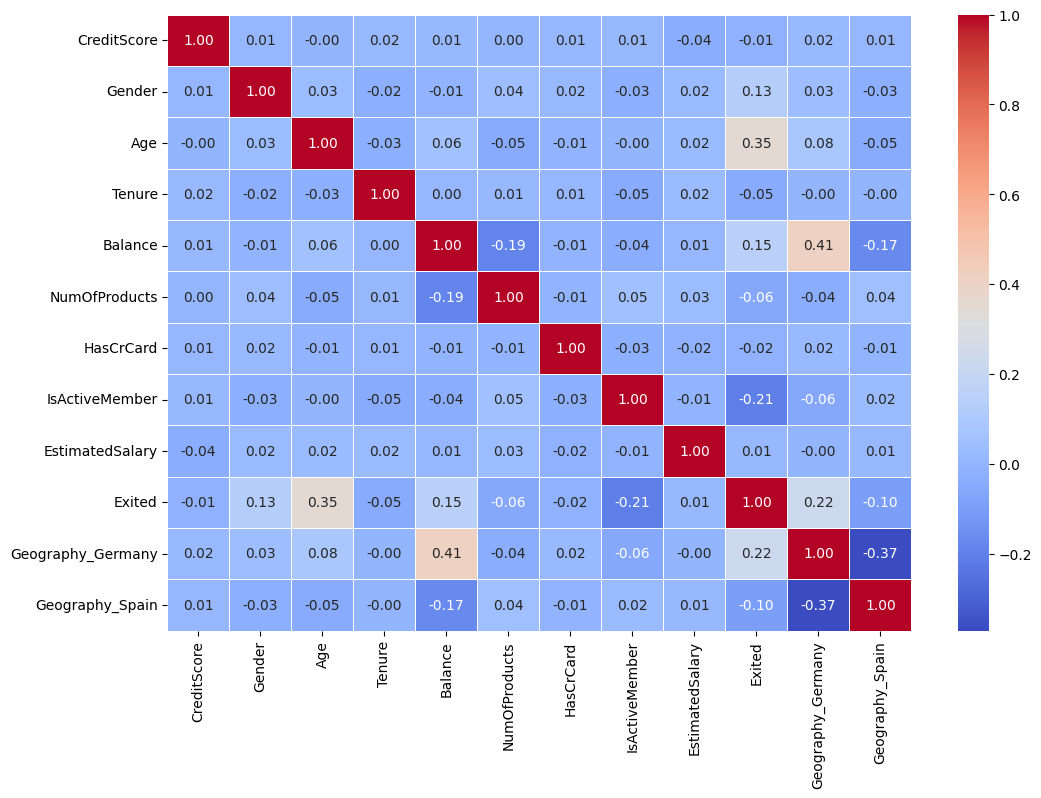

In [18]:
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)

plt.show()



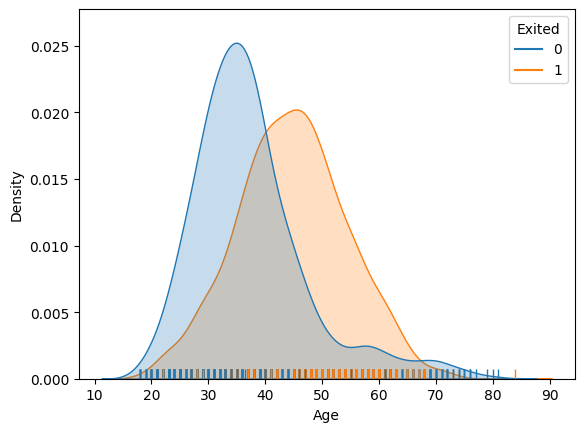

In [19]:
sns.kdeplot(data=df, x='Age', hue='Exited', fill=True)
sns.rugplot(data=df, x='Age', hue='Exited')
plt.show()

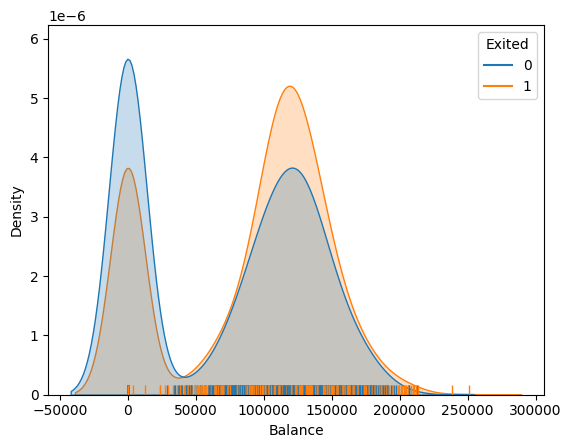

In [20]:
sns.kdeplot(data=df, x='Balance', hue='Exited', fill=True)
sns.rugplot(data=df, x='Balance', hue='Exited')
plt.show()

In [21]:
df[df['Balance'] < 0]

,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain


In [22]:
import numpy as np

df['IsZeroBalance'] = np.where(df['Balance'] == 0, 1, 0)
df.head()

,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain,IsZeroBalance
0,674,0,45.0,7,142072.02,1,1.0,0.0,37013.29,0,0.0,0.0,0
1,438,1,54.0,2,0.00,1,0.0,0.0,191763.07,1,0.0,1.0,1
2,749,0,47.0,9,110022.74,1,0.0,1.0,135655.29,1,1.0,0.0,0
3,724,0,34.0,6,118235.70,2,0.0,0.0,157137.23,0,1.0,0.0,0
4,586,1,46.0,0,0.00,3,0.0,1.0,131553.82,1,0.0,0.0,1


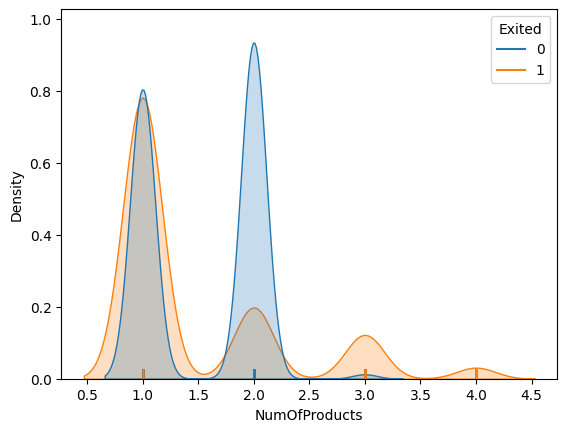

In [23]:
sns.kdeplot(data=df, x='NumOfProducts', hue='Exited', fill=True)
sns.rugplot(data=df, x='NumOfProducts', hue='Exited')
plt.show()

**EDA Conclusions**

There are many important conclusions we can extract from this Exploratory Data Analysis:
        
    1. The amount of customers in the database that 'Exited' (i.e. == 0) was vastly greater than those who are retained (i.e. == 1). Therefore, data balancing was the immidiate first step.

    2. The heatmap showed an important correlation between the feature 'Age' and the target label 'Exited' — of course, we don't want to base our model's accuracy on when a customer is most likely to die, although that is almost never the case for this database.  
        a. Therefore, we plot a Kernel Density Estimate Plot. This helps us visualize an important spot regarding customer Age, and the density of cases where they churn (exit).We observe that around 40 years of age, there is a shifting point for customer churning.
    
    3. We do the same KDE plot for those features that might have an impact on the model's prediction, like 'Balance' and 'NumOfProducts'. 
        a. In the case of 'Balance', we find that there are customers with a balance == 0. Therefore, we create a new column 'IsZeroBalance'. 

For these reasons, I have evidence to justify the use of a Decision Tree model instead of a Logistic Regression. 

### ML Pipeline

In this section the students are required to create a ML pipeline to predict whether the customer left the bank or not.

In [24]:
# import packages
import pandas as pd

In [39]:
# Train a decision tree model using the `train sample`
X = df.drop('Exited', axis=1)
y = df['Exited']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = DecisionTreeClassifier(max_depth=6, random_state=42)
model.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=6, random_state=42)

In [35]:
from sklearn.metrics import accuracy_score, recall_score, f1_score, classification_report, confusion_matrix

In [40]:
y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f'Accuracy: {accuracy:.4f}')
print(f'Recall: {recall:.4f}')
print(f'F1 Score: {f1:.4f}')

Accuracy: 0.7514
Recall: 0.7641
F1 Score: 0.7570


*Let's improve this model before integration to MLFlow*

In [43]:
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV

In [42]:
scores = cross_val_score(model, X, y, cv=5, scoring='f1')

print(f"Average F1 Score: {scores.mean():.2%}")
print(f"Standard Deviation: {scores.std():.2%}")

Average F1 Score: 76.27%
Standard Deviation: 1.82%


In [44]:
param_grid = {
    'max_depth': [3, 5, 7, 10],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'criterion': ['gini', 'entropy']
}

grid_search = GridSearchCV(DecisionTreeClassifier(), param_grid, cv=5, scoring='f1')
grid_search.fit(X_train, y_train)

print(f"Best Parameters: {grid_search.best_params_}")
best_model = grid_search.best_estimator_

Best Parameters: {'criterion': 'gini', 'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 2}


In [48]:

best_tree = grid_search.best_estimator_

y_pred_best = best_tree.predict(X_test)

print("--- New Tree Results ---")
print(classification_report(y_test, y_pred_best))

--- New Tree Results ---
              precision    recall  f1-score   support

           0       0.74      0.72      0.73       363
           1       0.73      0.75      0.74       373

    accuracy                           0.74       736
   macro avg       0.74      0.74      0.74       736
weighted avg       0.74      0.74      0.74       736



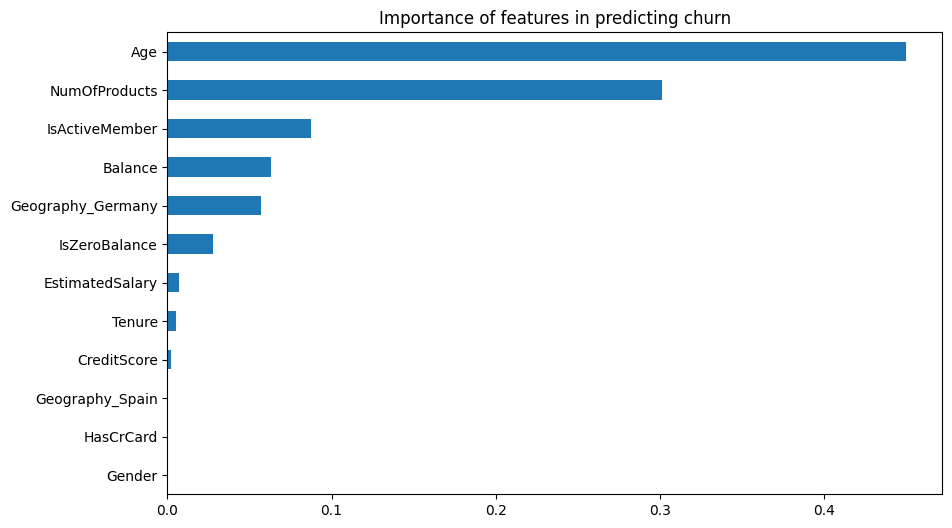

In [46]:
importances = pd.Series(best_tree.feature_importances_, index=X.columns)

importances.sort_values().plot(kind='barh', figsize=(10, 6))
plt.title('Importance of features in predicting churn')
plt.show()

In [49]:
def overfitting(model, X_train, X_test, y_train, y_test, name):
    train_score = model.score(X_train, y_train)
    test_score = model.score(X_test, y_test)
    gap = train_score - test_score

    print(f"--- {name} ---")
    print(f"Training Accuracy: {train_score:.4f}")
    print(f"Testing Accuracy:  {test_score:.4f}")
    print(f"Overfitting: {gap:.4f}")

overfitting(model, X_train, X_test, y_train, y_test, "Original Tree")
overfitting(best_tree, X_train, X_test, y_train, y_test, "Optimized Tree")

--- Original Tree ---
Training Accuracy: 0.7959
Testing Accuracy:  0.7514
Overfitting: 0.0445
--- Optimized Tree ---
Training Accuracy: 0.7687
Testing Accuracy:  0.7364
Overfitting: 0.0323


### MLFlow Integration

In this section the students are required to track the model and the parameters into MLFlow.

In [52]:
# import packages for mlfow
import mlflow
from mlflow.models import infer_signature

In [51]:
import sys
!{sys.executable} -m pip install mlflow

Start a local Tracking server on port 8080 - it is necessary to import mlflow and open a new terminal

In [53]:
# Set our tracking server uri for logging on port 8080
mlflow.set_tracking_uri(uri="http://127.0.0.1:5001")

Visit the MLFlow UI on `http://127.0.0.1:8080`

In [54]:
# Create a new MLflow Experiment called `Practice Experiment - {Your Name}`
mlflow.set_experiment("Practice Experiment - Andres Rodarte")

2026/05/15 15:32:30 INFO mlflow.tracking.fluent: Experiment with name 'Practice Experiment - Andres Rodarte' does not exist. Creating a new experiment.


<Experiment: artifact_location='mlflow-artifacts:/695989976875753577', creation_time=1778851950926, experiment_id='695989976875753577', last_update_time=1778851950926, lifecycle_stage='active', name='Practice Experiment - Andres Rodarte', tags={}>

In [55]:
# Start an MLflow run
with mlflow.start_run():
    mlflow.log_params(grid_search.best_params_)

    # Log the loss metric
    mlflow.log_metric("f1_score", f1)

    # Set a tag that we can use to remind ourselves what this run was for
    mlflow.set_tag("model_type", "Decision Tree Classifier")

    # Infer the model signature
    signature = infer_signature(X_train, best_tree.predict(X_train))

    # Log the model
    mlflow.sklearn.log_model(
        best_tree, artifact_path="churn_model", signature=signature, registered_model_name="Churn_DT_Model" )

/Users/andresrodartee/mlops-and-system-design/.venv-2/lib/python3.9/site-packages/mlflow/types/utils.py:452: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details.
  warnings.warn(
2026/05/15 15:34:20 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
Successfully registered model 'Churn_DT_Model'.
2026/05/15 15:34:22 INFO mlflow.store.model_registr

🏃 View run resilient-stoat-781 at: http://127.0.0.1:5001/#/experiments/695989976875753577/runs/dcf505f7c7db47fe96052b2d44a1abf0
🧪 View experiment at: http://127.0.0.1:5001/#/experiments/695989976875753577


Created version '1' of model 'Churn_DT_Model'.


### Keep practicing

In [ ]:
# Create a new experiment using other models or different parameters
...